In [1]:
# import necessary libraries
import numpy as np
import pandas as pd

In [2]:
# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# import dataset
data=pd.read_csv('../data/banglore.csv')
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
data.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
data['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [6]:
data['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr', '16-Jan', '14-Jul'], dtype=object)

In [7]:
# fill na values in 'location' column
data['location']=data['location'].fillna('Other')

In [8]:
# remove locations with less than 10 occurrences
loc_count=data['location'].value_counts()
data['location']=data['location'].apply(lambda x: 'other' if loc_count[x]<=10 else x)

In [9]:
# check for null values
data.isnull().sum()

area_type          0
availability       0
location           0
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [10]:
# extract bhk from size in integer format
data.dropna(subset=['size'],inplace=True)
data['size'] = data['size'].apply(lambda x: int(x.split(' ')[0]))

In [11]:
# convert availability to ready to move or not
def convert(x):
    if x=='Ready To Move':
        return x
    else:
        return 'Not ready'
data['availability']=data['availability'].apply(convert)
data['availability'].unique()

array(['Not ready', 'Ready To Move'], dtype=object)

In [12]:
# drop society column
data.drop('society',axis=1,inplace=True)

In [13]:
data.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Not ready,Electronic City Phase II,2,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,1200,2.0,1.0,51.00


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13304 non-null  object 
 1   availability  13304 non-null  object 
 2   location      13304 non-null  object 
 3   size          13304 non-null  int64  
 4   total_sqft    13304 non-null  object 
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13304 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 935.4+ KB


In [15]:
# convert total_sqft to numerical values
def convert_sqft_to_num(x):
    if '-' in x:
        tokens = x.split('-')
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None
data['total_sqft'] = data['total_sqft'].apply(convert_sqft_to_num)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13304 non-null  object 
 1   availability  13304 non-null  object 
 2   location      13304 non-null  object 
 3   size          13304 non-null  int64  
 4   total_sqft    13258 non-null  float64
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13304 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 935.4+ KB


In [17]:
data.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Not ready,Electronic City Phase II,2,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,1200.0,2.0,1.0,51.00


In [18]:
data.isnull().sum()

area_type         0
availability      0
location          0
size              0
total_sqft       46
bath             57
balcony         593
price             0
dtype: int64

In [19]:
# fill na values with median
data['total_sqft']=data['total_sqft'].fillna(data['total_sqft'].median())
data['bath']=data['bath'].fillna(data['bath'].median())
data['balcony']=data['balcony'].fillna(data['balcony'].median())

In [20]:
# one hot encoding for categorical columns
data=pd.get_dummies(data,columns=['area_type','availability','location'],drop_first=True,dtype=int)
data.head()

,size,total_sqft,bath,balcony,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_Ready To Move,location_1st Block Jayanagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,2,1056.0,2.0,1.0,39.07,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,2600.0,5.0,3.0,120.00,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1440.0,2.0,3.0,62.00,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3,1521.0,3.0,1.0,95.00,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2,1200.0,2.0,1.0,51.00,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='total_sqft', ylabel='price'>

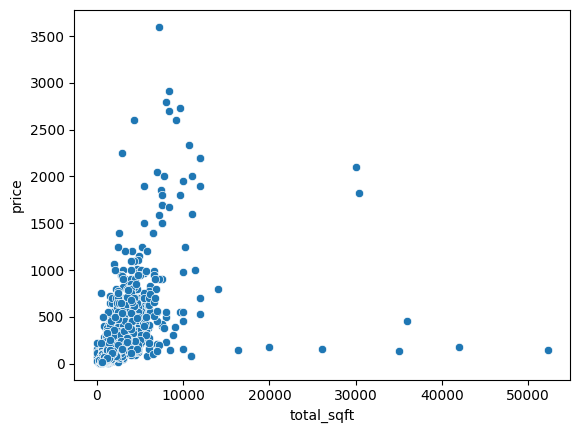

In [21]:
sns.scatterplot(x='total_sqft',y='price',data=data)

In [22]:
# remove outliers based on price per sqft
# price*100000 because price is in lakhs
data['price_per_sqft']=data['price']*100000/data['total_sqft']
data=data[data['price_per_sqft']<data['price_per_sqft'].quantile(0.97)]
data=data[data['price_per_sqft']>data['price_per_sqft'].quantile(0.03)]
data.drop('price_per_sqft',axis=1,inplace=True)

<Axes: xlabel='total_sqft', ylabel='price'>

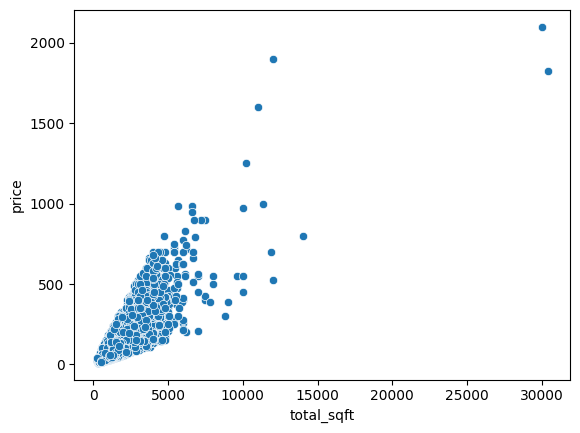

In [23]:
sns.scatterplot(x='total_sqft',y='price',data=data)

In [24]:
# remove outliers based on total_sqft per bhk
data=data[data['total_sqft']/data['size']>=250]

In [25]:
x=data.drop('price',axis=1)
y=data['price']

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
lr=LinearRegression()
lr_cv=cross_val_score(lr,X_train,y_train,cv=5,scoring='neg_mean_absolute_error')
print(-lr_cv.mean())

26.802045164259926


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

grid_param={
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20,30],
    'min_samples_leaf':[1,2,4]
}

grid=GridSearchCV(RandomForestRegressor(random_state=42),param_grid=grid_param,cv=5,n_jobs=-1,verbose=3,scoring='neg_mean_absolute_error')
grid.fit(X_train,y_train)
print(-grid.best_score_)
rf=grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
23.17513697070089


In [29]:
# random forest performs better than linear regression based on cross validation mean absolute error

In [30]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

0.78316073254814
22.84105183541934
2083.452952648348
45.64485680389794


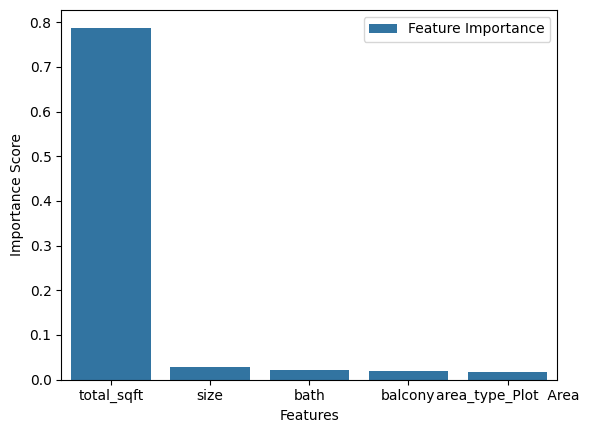

In [31]:
# feature importance plot
imp=pd.Series(rf.feature_importances_,index=x.columns).sort_values(ascending=False).head(5)
sns.barplot(x=imp.index,y=imp.values,label='Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()